In [1]:
import numpy as np
import matplotlib.pyplot as plt

from bayesian_network import BayesNet, Variable
from utils import sample_categorical, get_default_bayes_net

In [2]:
# this only works if Problem_2 runs without any errors!
from ipynb.fs.full.Problem_2 import sample_lw

Help on function sample_categorical in module utils:

sample_categorical(dist: numpy.ndarray) -> numpy.int64
    Draws a single sample from a categorical distribution.
    :param dist: NumPy array listing the probability of each outcome.
    :returns: Index of the sampled element.

Help on function sample_categorical in module utils:

sample_categorical(dist: numpy.ndarray) -> numpy.int64
    Draws a single sample from a categorical distribution.
    :param dist: NumPy array listing the probability of each outcome.
    :returns: Index of the sampled element.

[[[0.04107543 0.04107543]
  [0.38329027 0.38329027]]

 [[0.95892457 0.95892457]
  [0.61670973 0.61670973]]]


# Gibbs Sampling

<div class="alert alert-warning">
Implement the Gibbs sampling algorithm.
</div>

In Gibbs sampling, we sample directly from the target distribution $P_{\mathcal{B}}( \mathbf{Y} \mid \mathbf{E}=\mathbf{e})$ ($\mathbf{Y}$ denotes the set of non-evidence variables). We do this by implicitly constructing a sequence of proposal distributions that converge to the target distribution.

## Implementation

Implement
- `resampling_distribution`,
- `sample_gibbs`, and
- `gibbs_sampling`.

`resampling_distribution` computes the re-sampling distribution for a given variable.

`sample_gibbs` samples a sequence of random events according to all the relevant re-sampling distributions. 

`gibbs_sampling` approximates $P( X \mid \mathbf{E}=\mathbf{e})$ from a sequence of random events. Again, we will only consider probabilistic queries with one query variable $X$.

### Pre-computing the Re-sampling Distribution


Before we implement the Gibbs sampling algorithm, let us first write a helper function, which pre-computes the re-sampling distribution $P(X \mid mb(X))$ for an arbitrary variable $X$ in a given Bayesian Network.

Consider the following Bayesian network:

<img width='30%' src='img/bn.svg'>

To pre-compute $P(B \mid mb(B)) = P(B \mid A, C, D)$, we only need the conditional distribution of the $B$ and all of B's children, i.e., $P(B \mid A)$ and $P(D \mid B, C)$


<img width='30%' src='img/mb.png'>


The re-sampling distribution of $B$ can then be computed as follows: $P(B \mid A, C, D) = \frac{P(B \mid A) \cdot P(D \mid B, C)}{\sum_{b \in val(B)} P(B=b \mid A) \cdot P(D \mid B=b, C)}$

As an example, let's compute the re-sampling distribution for $B$ with NumPy. First, let us create the bayes net:

In [3]:
# initialize the Bayes net
_A_, _B_, _C_, _D_, _E_ = 0, 1, 2, 3, 4

A = np.array([0.2, 0.8])
B_A = np.array([[0.9, 0.2], [0.1, 0.8]])
C = np.array([0.9, 0.1])
D_BC = np.array([[[0.1, 0.2], [0.99, 0.8]], [[0.9, 0.8], [0.01, 0.2]]])
E_C = np.array([[0.7, 0.4], [0.3, 0.6]])
            
bayes_net = BayesNet(
    (A, [_A_]),
    (B_A, [_B_, _A_]),
    (C, [_C_]),
    (D_BC, [_D_, _B_, _C_]),
    (E_C, [_E_, _C_])
)

We can use the (conditional) probability distribution table of each variable (`variable.pdt`) to compute the re-sampling distribution. Note that the axes of `variable.pdt` are sorted by the variables's IDs and singleton dimensions are inserted for non-parent variables. This will make computations easier b/c we don't have to swap dimensions or insert empty dimensions for broadcasting:

In [4]:
print('Shape of P(B | A):    ', bayes_net[_B_].pdt.shape)
print('Shape of P(D | B, C): ', bayes_net[_D_].pdt.shape)

Shape of P(B | A):     (2, 2, 1, 1, 1)
Shape of P(D | B, C):  (1, 2, 2, 2, 1)


Computing $P(B \mid A, C, D) = \frac{P(B \mid A) \cdot P(D \mid B, C)}{\sum_{b \in val(B)} P(B=b \mid A) \cdot P(D \mid B=b, C)}$ is then easy:

In [5]:
# compute the rdt
rdt = bayes_net[_B_].pdt * bayes_net[_D_].pdt 
rdt = rdt / rdt.sum(axis=_B_, keepdims=True)

print(rdt.shape)

(2, 2, 2, 2, 1)


The dimensions of the re-sampling distribution table are also sorted by variable id, and singleton dimensions of size 1 are inserted for non-Markov-blanket variables. This is also the expected output format of the *resampling_distribution* function.

## Pre-computing All the Re-sampling Distributions

The `BayesNet` class has an optional constructor argument that have not used so far. This argument takes a function that computes the re-sampling distribution for a given variable. If this is provided, the `BayesNet` will use it to pre-compute re-sampling distribution tables for all its variables upon construction. These will become useful when we implement Gibbs sampling.

<div class="alert alert-warning">
    Implement the <i>resampling_distribution</i> function, which computes the re-sampling distribution for a given variable. (2 points)
</div>

`resampling_distribution` takes two parameters:
- `variable` is a `Variable` object for which the re-sampling distribution is to be computed.
- `bayes_net` is a `BayesNet` object which holds the (conditional) probability distribution table of each variable.

`resampling_distribution` returns a tuple containing two objects:
- a `np.ndarray` containing the re-sampling distribution $P(X \mid \textit{mb}(X))$ of the variable. The dimensions of the re-sampling distribution table must be sorted by variable id, and singleton dimensions of size 1 must be inserted for non-Markov-blanket variables.
- a `set` containing the IDs of all variables in $\textit{mb}(X)$. 

Hints:
 - `variable.parents` and `variable.children` will give you the ids of all parent and child variables, respectively.
 - `bayes_net[i]` returns the variable object with id `i`
 - `variable.pdt` gives the conditional probability distribution table of variable given its parents. The axis of this table are sorted by variable id, and singleton dimensions of size 1 are inserted for parent variables.
 - use `mb.add` or `mb.union` to add new variables to the `set`
 - use `mb.remove` or `mb.difference` to remove variables from the `set`

In [ ]:
def resampling_distribution(variable: Variable, bayes_net: BayesNet):
    '''
    Computes the resampling distribution given a variable and a Bayesian network.
    :param variable: The variable for which to compute the resampling distribution.
    :param bayes_net: A Bayesian network of type BayesNet. The bayes net is used to obtain the
                      probability table from child variables.
    :returns: A tuple containing the resampling distribution ('rdt') and a list containing
              the IDs of variables in the Markov blanket ('mb').
    '''
    
    rdt, mb = None, None
    
    
    X = variable.id

    #1) Markov blanket
    mb = set()

    # parents
    for p in variable.parents:
        mb.add(p)

    # children + co-parents
    for c in variable.children:
        mb.add(c)
        for p in bayes_net[c].parents:
            if p != X:
                mb.add(p)

    if X in mb:
        mb.remove(X)

    # 2) Multiply all relevant factors
    # start with P(X | parents)
    rdt = variable.pdt.copy()

    # multiply by P(child | parents(child))
    for c in variable.children:
        rdt = rdt * bayes_net[c].pdt

    #3) MATCH BN DIMENSIONS EXACTLY 
    
    while rdt.ndim < len(bayes_net):
        rdt = np.expand_dims(rdt, axis=-1)

    # reorder axes so axis i corresponds to variable i

    rdt = np.moveaxis(rdt, list(range(rdt.ndim)), list(range(len(bayes_net))))

    # 4) normalize along axis X 
    rdt = rdt / rdt.sum(axis=X, keepdims=True)

    return rdt, mb

In [38]:
import traceback
any_failed = False
try:
    # get_default_bayes_net returns the same Bayes net as defined above; just in case the variable was modified...
    bayes_net = get_default_bayes_net()
    
    # compute resampling distribution table of P( B | mb(B) ); same as above 
    rdt = bayes_net[_D_].pdt * bayes_net[_B_].pdt
    rdt = rdt / rdt.sum(axis=_B_, keepdims=True)
    # set containing all the indices of the variables in mb(B)
    mb = {_A_, _D_, _C_}
    
    expected = rdt, mb
    actual = resampling_distribution(bayes_net[_B_], bayes_net)
    
    #sanity checks
    assert type(actual[1]) == type(expected[1]), f'Set of parents has wrong data type.\n Expected: {type(expected[1])}\nGiven: {type(actual[1])}'
    assert actual[1] == expected[1], f'The variables in the Markov blanket are not correct.\n Expected: {expected[1]}\nGiven: {actual[1]}'
    
    assert expected[0].shape == actual[0].shape, f'Resampling distribution has the wrong shape!\nExpected: {expected[0].shape}\nGiven:\t  {actual[0].shape}'
    assert expected[0].dtype == actual[0].dtype, f'Wrong numpy array data type!\nExpected: {expected[0].dtype}\nGiven:\t  {actual[0].dtype}'
    assert np.all(np.isclose(8, actual[0].sum())), f'Incorrect normalization. Sum of CPDT is: {actual[0].sum()}'
    assert np.all(np.isclose(expected[0], actual[0])), f'Computation of resampling distribution did not yield the correct result.'

  
except Exception as e:
    print("Error:", e)
    traceback.print_exception(type(e), e, e.__traceback__)
    any_failed = True
assert not any_failed, "See error message above..."

### Gibbs Sampling

<div class="alert alert-warning">
Implement the <i>sample_gibbs</i> function. (3 points)
</div>

`sample_gibbs` takes five parameters:
- `bayes_net` is a `BayesNet` object to draw samples from (it uses your `resampling_distribution()` from above).
- `sample_size` is the number of samples to use for the estimation.
- `evidence` is a dictionary of variable_ids (keys) and values (values) assigned to the variable. (optional, default = {})
- `burn_in_samples` gives the number of burn-in steps to take (>= 0). (optional, default = 0)
- `sample_distance` gives the number of steps to take to get the next sample (> 0). (optional, default = 1)

`sample_gibbs` function must return one object:
- samples from $P_{\mathcal{B}}( \mathbf{Y} \mid \mathbf{E}=\mathbf{e})$ of type `np.ndarray`, with shape `(sample_size, len(bayes_net))`


Initialize the Markov chain with a random event drawn from $\mathcal{B}_{\mathbf{E}=\mathbf{e}}$. The first element in the sample is the random event obtained after performing a total of `burn_in_samples` steps. Thereafter, perform `sample_distance` steps to obtain each one of the next `sample_size` samples. Hence, `burn_in_samples + (sample_size - 1) * sample_distance` steps will be performed in total.

To make your implementation comparable to ours, sample the new values for the non-evidence variables in the topological order provided by the BayesNet class, i.e. `for variable in bayes_net: ...`.


**Hint**:
- `sample_lw(bayes_net, 1, evidence=evidence)[0]` draws an initial sample from $\mathcal{B}_{\mathbf{E}=\mathbf{e}}$
  - we imported `sample_lw` for you; no need to copy-paste it from the previous notebook
- the pre-computation of the re-sampling distributions is handled by the BayesNet (we pass your `resampling_distribution` function to the BayesNet object at instantiation time)
- to obtain the distribution $P(X \mid \mathit{mb}(X))$, simply call `variable(sample, resampling=True)`; this uses the precomputed re-sampling distribution instead of `variable.pdt`, and is only available because we passed `resampling_distribution` to the BayesNet constructor
- it may help to define a function that performs $n$ Gibbs steps on a sample, and reuse it &mdash; you can even define a local function in the middle of `sample_gibbs()`! mind that Python arguments are passed by reference, use `.copy()` on an `ndarray` if needed.


In [ ]:
def sample_gibbs(bayes_net: BayesNet, sample_size: int, evidence: dict={}, burn_in_samples: int=0, 
                 sample_distance: int=1):
    '''
    Returns sample_size samples from the target distribution P( Y | E=e ).
    :param bayes_net: A Bayesian network of type BayesNet.
    :param sample_size: The number of samples to use for the estimation.
    :param evidence: A dictionary of evidence variables (keys, int) and their correponding values (values, int).
    :param burn_in_samples: The number of burn-in samples to throw away (>= 0).
    :param sample_distance: Use only every n-th sample. (> 0)
    :returns: A NumPy array of type np.int64 with shape (sample_size, len(bayes_net)).
    '''
    
    assert burn_in_samples >= 0
    assert sample_distance > 0
    
    samples = np.empty((sample_size, len(bayes_net)), np.int64)
    num_vars = len(bayes_net)
    
  
    # initial constrained sample
    state = sample_lw(bayes_net, 1, evidence=evidence)[0].squeeze().copy()

    # test uses BN’s internal order
    vars_internal = list(bayes_net)
    non_evidence_vars = [v for v in vars_internal if v.id not in evidence]

    def sweep(state):
        """One Gibbs sweep = update ALL non-evidence variables in BN order."""
        for var in non_evidence_vars:
            vid = var.id
            dist = var(state, resampling=True).squeeze()
            state[vid] = int(sample_categorical(dist))

    # burn-in sweeps
    for _ in range(burn_in_samples):
        sweep(state)

    samples[0] = state.copy()

    # spaced sweeps
    for i in range(1, sample_size):
        for _ in range(sample_distance):
            sweep(state)
        samples[i] = state.copy()

    return samples

In [43]:
any_failed = False
try:
    # get_default_bayes_net returns the same Bayes net as defined above; just in case the variable was modified...
    # this time we also pass the function to pre-compute the resampling distributions
    bayes_net = get_default_bayes_net(resampling_distribution=resampling_distribution)
    print([v.id for v in bayes_net])
    np.random.seed(0)
    expected = np.array([[0, 0, 0, 1, 0], [0, 0, 0, 0, 0], [0, 0, 1, 0, 0],
                         [0, 0, 0, 0, 0], [0, 0, 0, 1, 0], [0, 0, 0, 1, 1]], dtype=np.int64)
    actual = sample_gibbs(bayes_net, 6, {0:0}, 7, 3)
    
    # sanity checks
    assert type(actual) == type(expected), f'\nWrong output type!\nExpected: {type(expected)}\nGiven:\t  {type(actual)}'
    assert actual.shape == expected.shape, f'\nWrong output shape!\nExpected: {expected.shape}\nGiven:\t  {actual.shape}'
    assert actual.dtype == expected.dtype, f'\nWrong numpy array data type!\nExpected: {expected.dtype}\nGiven:\t  {actual.dtype}'
    assert np.all(np.isclose(actual, expected)), f'samples and reference samples do not match.\nExpected:\n{expected}\n\nGiven:\n{actual}\n\nIf your last two samples are the same, this may hint at a bug.'
        
except Exception as e:
    print("Error:", e)
    traceback.print_exception(type(e), e, e.__traceback__)
    any_failed = True
    
assert not any_failed, "See error message above..."

[2, 4, 0, 1, 3]


<div class="alert alert-warning">
Implement the <i>gibbs_sampling</i> function to estimate the probability distribution over the query variable $X$ given the evidence $\mathbf{E}=\mathbf{e}$, $P(X \mid \mathbf{E}=\mathbf{e})$. (2 points)
</div>

`gibbs_sampling` takes six parameters:
- `bayes_net` is a `BayesNet` object to draw samples from.
- `query_variable_id` is the id of the query variable (int).
- `evidence` is a dictionary of variable_ids (keys) and values (values) assigned to the variable. (optional, default = {})
- `sample_size` gives the number of samples to use for the estimation (optional, default = 100).
- `burn_in_samples` gives the number of burn-in samples to throw away (>= 0). (optional, default = 0)
- `sample_distance` gives the number of steps to take to get the next sample (> 0). (optional, default = 1)

`gibbs_sampling` function must return one object:
-  The probability distribution over variable $X$ of type `np.ndarray` with shape `(bayes_net[query_variable_id].num_values,)`.


**Hint**:
- use `np.bincount` to count the number of occurrences of each value; don't forget to set minlength
- the number of values a variable can take can be obtained via `variable.num_values`

In [46]:
def gibbs_sampling(bayes_net: BayesNet, query_variable_id: int, evidence: dict={}, 
                   sample_size: int=100, burn_in_samples: int=0, sample_distance: int=1):
    '''
    Estimates the distribution of the query variale given the value of the evidence variables.
    :param bayes_net: A Bayesian network of type BayesNet.
    :param query_variable_id: The id of the query variable (int).
    :param evidence: A dictionary of evidence variables (keys, int) and their correponding values (values, int).
    :param sample_size: The number of samples to use for the estimation.
    :burn_in_samples: The number of burn-in samples to throw away (>= 0).
    :param sample_distance: Use only every n-th sample. (> 0)
    :returns: A NumPy array of type np.float64 representing the conditional distribution of the query variable given evidence. 
    '''
    
    # draw samples...
    smpls = sample_gibbs(
        bayes_net, 
        sample_size, 
        evidence=evidence, 
        burn_in_samples=burn_in_samples, 
        sample_distance=sample_distance
    )
    
         # extract the column of query variable
    q_vals = smpls[:, query_variable_id]
    
    # number of possible values of the query variable
    num_vals = bayes_net[query_variable_id].num_values
    
    # count occurrences
    counts = np.bincount(q_vals, minlength=num_vals).astype(np.float64)
    
    # normalize
    distribution = counts / counts.sum()
    
    return distribution

In [45]:
any_failed = False
try:
    # get_default_bayes_net returns the same Bayes net as defined above; just in case the variable was modified...
    # again, we also pass the function to pre-compute the resampling distributions
    bayes_net = get_default_bayes_net(resampling_distribution=resampling_distribution)
    
    np.random.seed(0)
    expected = np.array([0.25, 0.75], dtype=np.float64)
    actual = gibbs_sampling(bayes_net, 0, {2:1}, 100, 5, 3)
    
    # sanity checks
    assert type(actual) == type(expected), f'\nWrong output type!\nExpected: {type(expected)}\nGiven:\t  {type(actual)}'
    assert actual.shape == expected.shape, f'\nWrong output shape!\nExpected: {expected.shape}\nGiven:\t  {actual.shape}'
    assert actual.dtype == expected.dtype , f'\nWrong numpy array data type!\nExpected: {expected.dtype}\nGiven:\t  {actual.dtype}'
    assert np.all(np.isclose(1, actual.sum())), f'Incorrect normalization. Sum of PDT is: {actual.sum()}'
    assert  np.all(np.isclose(actual, expected)), f'Wrong output value.'
    
except Exception as e:
    print("Error:", e)
    traceback.print_exception(type(e), e, e.__traceback__)
    any_failed = True
    
assert not any_failed, "See error message above..."

## Example

Reconsider the Bayesian Network from the previous problems:

<img width='30%' src='img/bn_new.svg'>

The conditional probability tables are given as:

<table style="float: left;margin:5px;"><tr><th>P(A)</th><th>$a_0$<br></th><th>$a_1$</th></tr><tr><td>-</td><td>0.2</td><td>0.8</td></tr></table>

<table style="float: left;margin:5px;"><tr><th>P(B | A)</th><th>$a_0$<br></th><th>$a_1$</th></tr><tr><td>$b_0$</td><td>0.9</td><td>0.2</td></tr><tr><td>$b_1$</td><td>0.1</td><td>0.8</td></tr></table>

<table style="float: left;margin:5px;"><tr><th rowspan="2">P(D | A, B)</th><th colspan="2">$a_0$<br></th><th colspan="2">$a_1$</th></tr><tr><td>$b_0$</td><td>$b_1$</td><td>$b_0$</td><td>$b_1$</td></tr><tr><td>$d_0$<br></td><td>0.1</td><td>0.2</td><td>0.01</td><td>0.8</td></tr><tr><td>$d_1$</td><td>0.9</td><td>0.8</td><td>0.99</td><td>0.2</td></tr></table>

<table style="float: left;margin:5px;"><tr><th>P(C|D)</th><th>$d_0$<br></th><th>$d_1$</th></tr><tr><td>$c_0$</td><td>0.95</td><td>0.15</td></tr><tr><td>$c_1$</td><td>0.05</td><td>0.85</td></tr></table>

<table style="float: left;margin:5px;"><tr><th>P(E | C)</th><th>$c_0$</th><th>$c_1$</th></tr><tr><td>$e_0$</td><td>0.9</td><td>0.4</td></tr><tr><td>$e_1$</td><td>0.1</td><td>0.6</td></tr></table>

In [48]:
_A_, _B_, _C_, _D_, _E_ = 0, 1, 2, 3, 4

A = np.array([0.2, 0.8])
B_A = np.array([[0.9, 0.2], [0.1, 0.8]])
C_D = np.array([[0.95, 0.15], [0.05, 0.85]])
D_AB = np.array([[[0.1, 0.2], [0.01, 0.8]], [[0.9, 0.8], [0.99, 0.2]]])
E_C = np.array([[0.9, 0.4], [0.1, 0.6]])
              
bayes_net = BayesNet(
    (A, [_A_]),
    (B_A, [_B_, _A_]),
    (C_D, [_C_, _D_]),
    (D_AB, [_D_, _A_, _B_]),
    (E_C, [_E_, _C_]), resampling_distribution=resampling_distribution
)

### Exact Computation
<div class="alert alert-warning">
This imports your computation fo $P(A \mid D, E)$ from the previous notebook.
</div>

In [49]:
# this only works if Problem_1 runs without any errors!
from ipynb.fs.full.Problem_1 import A_DE

### Comparison

Run the following code cell to plot the average [Kullback-Leibler divergence](https://en.wikipedia.org/wiki/Kullback%E2%80%93Leibler_divergence) between the exact distribution $P(A \mid D, E)$ and the approximations computed with Gibbs sampling. Different lines represent different value assignments to the evidence variables $D$ and $E$.

**Hint**: The computation of the approximations might take a while.

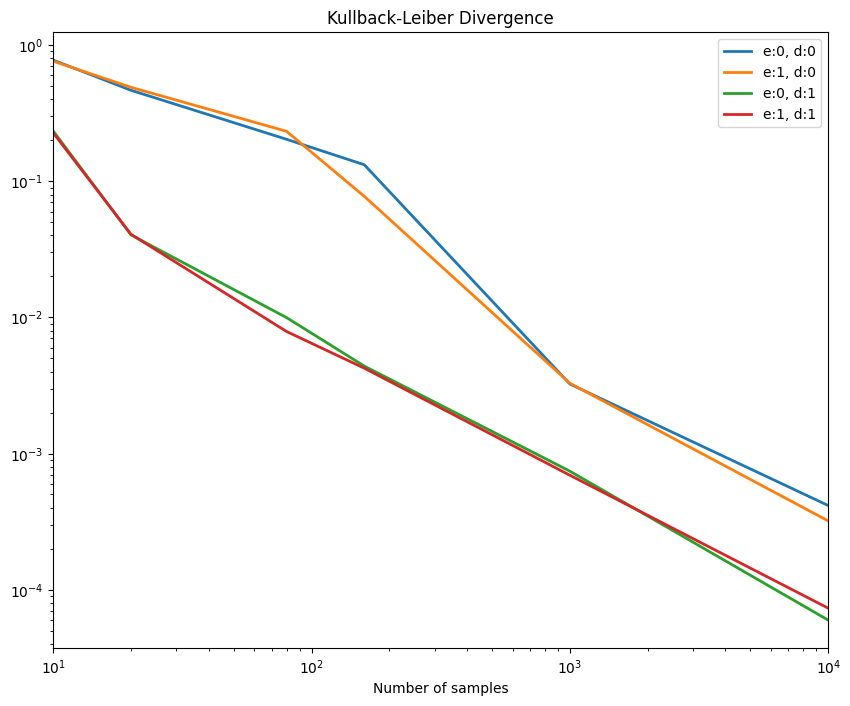

In [50]:
if __name__ == '__main__':
    from utils import approx_error
    
    np.random.seed(0)
    errs = {}
    sample_counts = np.array([10, 20, 80, 160 , 1000, 10000])
    
    # compute approximation error
    for d, e in zip([0, 0, 1, 1], [0, 1, 0, 1]):
        errs[(d, e)] = approx_error(
            bayes_net,
            gibbs_sampling,  
            A_DE[:, d, e],
            _A_,
            {_D_:d, _E_:e}, 
            sample_counts,
            n_runs=100,
            burn_in_samples=0,
            sample_distance=1
        )
    
    # plot
    plt.figure(figsize=(10, 8))
    plt.title('Kullback-Leiber Divergence')
    for d, e in zip([0, 0, 1, 1], [0, 1, 0, 1]):
        plt.plot(sample_counts, errs[(d, e)], label=f'e:{e}, d:{d}', lw=2)
        
    plt.legend()
    plt.xscale('log')
    plt.yscale('log')
    plt.xlim(sample_counts.min(), sample_counts.max())
    plt.xlabel('Number of samples')
    plt.show()

<div class="alert alert-warning">
Answer the following question. Keep your answer <b>concise</b>! (1 point)
</div>

Given the Bayesian Network from the example above, we want to approximate the probabilistic query $P(A \mid D=1, E=1)$. Consider the two cases:

* (1): We draw 100 samples from our implemented ```sample_gibbs``` function. 
* (2): We draw a total of 100 samples from our implemented ```sample_gibbs``` function. However, we start drawing samples only after we have performed 100 Gibbs Sampling steps, and we only take every 10th sample afterwards.

We approximate the result of the probabilistic query with the 100 samples drawn for each of the two scenarios (1) and (2). For which scenario do you expect the smaller approximation error? Explain why!

**Hint**: Use the code cell below to perform whatever analysis supports your answer. You can, for example, use the ```approx_error``` function (used to create the plot above) and experiment with the parameters ```burn_in_samples``` and ```sample_distance```. 

**Note**: Only your textual answer will be graded. The code cell only allows you to check if your intuition is correct.


Scenario (2) is expected to have a smaller approximation error, because the 100 burn-in steps reduce dependence on the initial state, and taking every 10th sample lowers autocorrelation between samples. The resulting samples are more independent and better represent the target distribution, leading to a more accurate estimate of P(A \mid D=1, E=1).

<div class="alert alert-warning">
Answer the following question. Keep your answer <b>concise</b>! (1 point)
</div>

Consider the Bayesian Network below consisting of three binary variables, $C_1$, $C_2$, and $Z$. $C_1$ and $C_2$ are two uniformly distributed, independent coins. $Z$ is the Exclusive OR applied to the outcome of $C_1$ and $C_2$. Can we successfully estimate the probabilistic query $P(C_1, C_2 \mid Z=1)$ using Gibbs Sampling? <b>Justify your answer!</b>
  
**Hint**: Use the code cell below to perform whatever analysis supports your answer. You may want to create the Bayesian Network defined below and pass it to your implemented ```sample_gibbs``` function. Look at the samples generated. Do you see a pattern?

**Note**: Only your textual answer will be graded. However, the code cell allows you to check if your explanation is correct.

<img width='30%' src='img/xor.png'>

<table style="float: left;margin:5px;"><tr><th>P(C1)</th><th>$\neg$$c_1$<br></th><th>$c_1$</th></tr><tr><td>-</td><td>0.5</td><td>0.5</td></tr></table>

<table style="float: left;margin:5px;"><tr><th>P(C2)</th><th>$\neg$$c_2$<br></th><th>$c_2$</th></tr><tr><td>-</td><td>0.5</td><td>0.5</td></tr></table>

<br><br><br>

<table style="float: left;margin:5px;"><tr><th rowspan="2">P($Z$ | $C_1$, $C_2$)</th><th colspan="2">$\neg$$c_1$<br></th><th colspan="2">$c_1$</th></tr><tr><td>$\neg$ c_2</td><td>c_2</td><td>$\neg$ c_2</td><td>c_2</td></tr><tr><td>$\neg$ z<br></td><td>1</td><td>0</td><td>0</td><td>1</td></tr><tr><td>z</td><td>0</td><td>1</td><td>1</td><td>0</td></tr></table>

No.
With the XOR evidence Z=1 the posterior mass is on two states (C_1,C_2)=(0,1) and (1,0) only. Single-site Gibbs updates one coin at a time; any single flip would violate Z=1, so the conditionals are degenerate and the chain stays in whatever of the two compatible states it was initialized in. Hence Gibbs (single-variable updates) cannot move between the two modes and gives a biased estimate. (Workarounds: use blocked updates that resample (C_1,C_2) jointly or use importance/LW sampling.)